# A.1.1 Estymacja Semiwariogramu

## Spis Treści

1. Wczytaj obserwacje.
2. Utwórz eksperymentalny semiwariogram.
3. Wyznacz manualnie funkcję semiwariogramu.
4. Wyznacz model automatycznie.
5. Eksportuj model.
6. Importuj model.

## Wprowadzenie

W tym samouczku nauczymy się jak przygotowywać dane do modelowania semiwariogramu, ręcznie ustawiać jego typ albo zautomatyzować ten proces. Porównamy różne modele semiwariogramów, wizualizując wyniki przebieg semiwariancji dla rosnącego dystansu.

Przeprowadzenie interpolacji przestrzennej nieznanych wartości za pomocą Krigingu wymaga wcześniejszego modelowania semiwariogramu, z tego względu jest to krok krytyczny, przez który musi przejść każdy geostatystyk.

Korzystamy z danych DEM, które przechowywane są w pliku `samples/point_data/txt/pl_dem.txt`.

## Import paczek

In [48]:
import numpy as np

import matplotlib.pyplot as plt

# Operacje wejścia i wyjścia
from pyinterpolate import read_txt
# Eksperymentalny semiwariogram
from pyinterpolate import build_experimental_variogram
# Teoretyczny semiwariogram
from pyinterpolate import TheoreticalVariogram, build_theoretical_variogram

## 1) Załaduj obserwacje

In [49]:
DATA = '../../datasets/samples/point_data/txt/pl_dem_epsg2180.txt'
dem = read_txt(DATA)

In [50]:
# Wyświetl kilka pierwszych obserwacji DEM

dem[-5:, :]

array([[2.55032701e+05, 5.47047700e+05, 6.29624100e+01],
       [2.54975796e+05, 5.45920408e+05, 2.03861294e+01],
       [2.54751735e+05, 5.41480271e+05, 4.03093376e+01],
       [2.54682103e+05, 5.40099921e+05, 2.19432678e+01],
       [2.54521994e+05, 5.36925123e+05, 5.15251350e+01]])

## 2) Stwórz eksperymentalny semiwariogram

Pierwszym krokiem analizy przestrzennej jest sprawdzenie korelacji między sąsiednimi obserwacjami w naszym zbiorze danych. Używamy wariogramów – wykresów odmienności par punktów (oś y) w funkcji rosnącej odległości między parami sąsiadów (oś x). Istnieją dwa „typy” wariogramów.

- **Eksperymentalny (semi)wariogram**: bezpośrednio pokazujący różnice pomiędzy parami punktów w określonych przedziałach. Wybierając zbyt krótkie kroki między przedziałami ryzykujemy, że semiwariogram będzie bardzo zaszumiony i niezdatny do modelowania. Z tego powodu . Używamy go do sprawdzenia, czy istnieje korelacja przestrzenna.
- **Teoretyczny (semi)wariogram**: to szczególna funkcja stosowana do wariogramu eksperymentalnego. Dopasowujemy funkcję z zadanego zbioru do punktów eksperymentalnych semiwariogramu i wybieramy model o najmniejszym możliwym błędzie. Mamy kilka modeli do wypróbowania i tylko trzy *hiperparametry* do kontrolowania ich zachowania.

Każdą analizę rozpoczynamy od wyznaczenia eksperymentalnego semiwariogramu. Służy do tego funkcja `build_experimental_variogram()`, która tworzy obiekt typu `ExperimentalVariogram` przechowujący model. Funkcja przyjmuje trzy parametry:

1. `input_array`: `numpy array` gdzie pierwsze kolumny to koordynaty a ostatnia kolumna reprezentuje obserwację `[[0, 0, 10], [0, 1, 20]]`,
2. `step_size`: semiwariogram obliczany jest na podstawie przedziałów odległości, nie wykreślamy każdej odległości między sąsiadami a grupujemy je w kilku albo kilkunastu przedziałach. Szerokoś takiego przedziału określa parameter `step_size`.Przykładowo, ustawiając `step_size` na `1000` to wszystkie pary punktów w odległościach między 0 a 1000 jednostek trafiają do jednego przedziału (tzw.: *lag*), którego środek wynosi 500,
3. `max_range`: maksymalna odległośc dla której przewidujemy wpływ sąsiedztwa. Przyjęło się, że jest to maksymalnie połowa rozmiarów analizowanego obszaru.

In [51]:
# Stwórz eksperymentalny semiwariogram

step_radius = 500  # metry
max_range = 10000  # metry

experimental_variogram = build_experimental_variogram(input_array=dem, step_size=step_radius, max_range=max_range)

In [52]:
# Jakim typem obiektu jest eksperymentalny semiwariogram?

type(experimental_variogram)

pyinterpolate.variogram.empirical.experimental_variogram.ExperimentalVariogram

Obiekt typu `ExperimentalVariogram` przechowuje następujące informacje:

- **semiwariancję** - czyli miarę niepodobieństwa w funkcji odległości,
- **kowariancję** - wskaźnik podobieństwa w funkcji odległości,
- **wariancję** zbioru danych.

Klasa `ExperimentalVariogram` ma dwie metody przydatne dla analityka:

1. Możemy poznac opisowe statystyki obiektu dzięki funkcji `print()`.
2. Metoda `plot()` wizualizuje przebieg semiwariancji, kowariancji i wariancji.

Sprawdźmy obie metody!

In [53]:
print(experimental_variogram)

+--------+--------------------+---------------------+--------------------+
|  lag   |    semivariance    |      covariance     |    var_cov_diff    |
+--------+--------------------+---------------------+--------------------+
| 500.0  | 14.716058620972868 |  480.99904783812127 | 8.821278469608444  |
| 1000.0 | 34.85400868491261  |  464.2196256667607  | 25.600700640969023 |
| 1500.0 | 57.712760007769795 |  433.73651582698574 | 56.08381048074398  |
| 2000.0 | 82.49483539006093  |  403.5799288984297  | 86.24039740929999  |
| 2500.0 | 111.4449493651956  |  364.9336781724029  | 124.88664813532682 |
| 3000.0 | 143.4007980025356  |  325.6459001433955  | 164.1744261643342  |
| 3500.0 | 175.10704725708965 |  284.4093681493841  | 205.41095815834564 |
| 4000.0 | 209.3522343651705  |  245.59671700665646 | 244.22360930107325 |
| 4500.0 | 244.46785072173265 |  204.4305639103993  | 285.3897623973304  |
| 5000.0 | 281.0897575749926  |  159.61259251127132 | 330.2077337964584  |
| 5500.0 | 315.6754922912

- `lag` to wartośc centralna przedziału,
- `semivariance` to miara niepodobieństwa,
- `covariance` to miara podobieństwa,
- `var_cov_diff` - różnica między wariancją a kowariancją. Idealnie powinna byc równa semiwariancji, ale jest to możliwe tylko wtedy kiedy przestrzenny proces jest procesem stacjonarnym drugiego stopnia. Jest to stosunkowo rzadki scenariusz w świecie rzeczywistym. Jednakże wartoś różnicy między wariancją a kowariancją powinna by w miarę zbliżona do semiwariancji nawet jeśli warunek stacjonarności nie jest spełniony (przynajmniej do maksymalnego zasięgu analizy).

Te same dane można przedstawic w formie wykresu, który czyta się znacznie wygodniej:

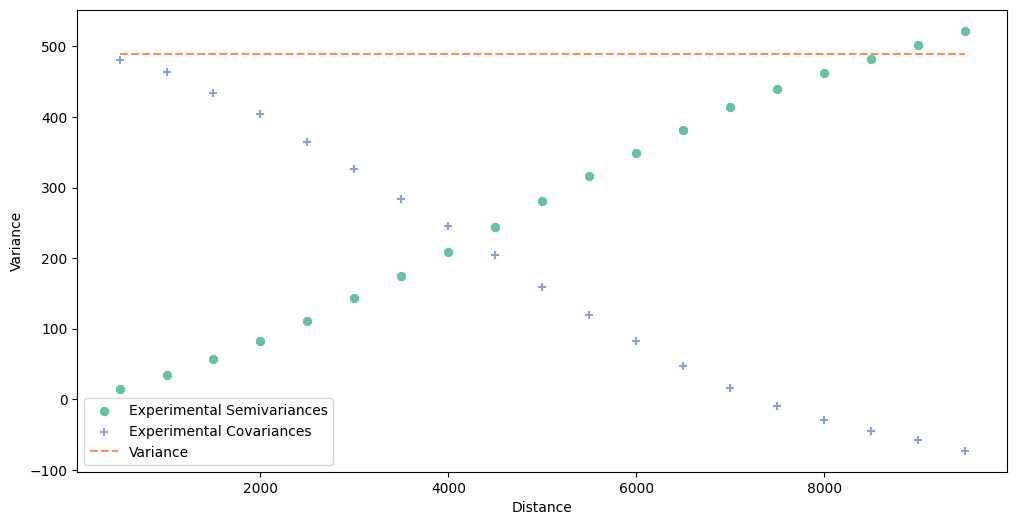

In [54]:
experimental_variogram.plot(plot_semivariance=True, plot_covariance=True, plot_variance=True)

Wykres przedstawia trzy przebiegi:

1. Koła to semiwariancja.
2. Znaki plus to kowariancja.
3. Przerywana linia to wariancja.

Semiwariancje i kowariancje wyglądają jak lustrzane odbicie, mają odbity trend. Dla semiwariancji **niepodobieństwo między parami punktów rośnie wraz z odległością między nimi**, a dla kowariancji **podobieństwo między parami punktów maleje wraz z odległością między nimi**.

W najlepszym możliwym scenariuszu, gdzie proces jest stacjonarny a średnia i wariancja obserwacji nie zmienia się wraz z odległością, różnica między wariancją a kowariancją powinna pokrywac się z semiwariancją. W tym przypadku nie jest to prawda, jednakże błąd nie jest bardzo duży.

Posiadając eksperymentalny wariogram `ExperimentalVariogram` możemy przystąpic do wyznaczania modelu teoretycznego opisującego semiwariancję.

## 3. Wyznacz ręcznie funkcję semiwariogramu

Posiadając eksperymentalne semiwariancje w funkcji odległości między parami punktów możemy rozpocząc modelowanie teoretycznego przebiegu opisującego niepodobieństwo między obserwacjami. Rolą specjalisty jest wybranie odpowiedniej funkcji opisującej semiwariogram z zestawu predefiniowanych modeli opisanych przez trzy parametry. Więcej na ten temat znajdziej w artykule tutaj: [Geostatistics: Theoretical Variogram Models](https://ml-gis-service.com/index.php/2022/04/01/geostatistics-theoretical-variogram-models/) (artykuł po angielsku).

Trzy parametry teoretycznego semiwariogramu to:

- Parametr **nugget**: początkowa wartośc niepodobieństwa dla odległości ~0. Domyślnie jest to 0, ale czasami może to byc wartośc dodatnia reprezentująca bias (niepewnośc) pomiarów i obserwacji.
- Parametr **sill**: jest miarą niepodobieństwa w punkcie gdzie semiwariogram się wypłaszcza a miara niepodobieństwa jest bliska maksimum (95% wariancji). Czasami ścisłe wyznaczenie tego parametru nie jest możliwe. Jeśli niepodobieństwo rośnie wykładniczo nie wiemy gdzie semiwariogram będzie się wypłaszczał. Wtedy najbezpieczniejsza opcja to ustawienie parametru blisko maksymalnej wariancji całego zbioru danych.
- Parametr **range**: odległośc w której semiwariogram osiąga wysycenie `sill`. Sąsiedzi w dystansie większym niż ta odległośc nie mają już dużego wpływu na konkretny punkt.

Analityk nie jest zobowiązany znac żadnego z tych parametrów, może również skorzystac z metody `.autofit()` klasy `TheoreticalVariogram` - parametry są obliczane w procesie minimalizacji błędu dopasowania do eksperymentalnego semiwariogramu. Jednakże w tym samouczku zbudujemy również model ręcznie.

### Modele analityczne

Modelując semiwariogram korzystamy z kilku predefiniowanych funkcji i porównamy ich skutecznośc:

* circular,
* cubic,
* exponential,
* gaussian,
* linear,
* power,
* spherical.

Każda z nich korzysta z trzech parametrów, które ustawimy następująco

- **sill** równe wariancji całego zbioru danych,
- **nugget** ustawiony na 0,
- **range** na 8000 metrów (mniej więcej na tej odległości eksperymentalny wariogram się wypłaszcza i jest bliski nasyceniu).

In [55]:
sill = experimental_variogram.variance
nugget = 0
var_range = 8000

In [56]:
# circular

circular_model = build_theoretical_variogram(experimental_variogram=experimental_variogram,
                                             model_name='circular',
                                             sill=sill,
                                             rang=var_range,
                                             nugget=nugget)

In [57]:
print(circular_model)

* Selected model: Circular model
* Nugget: 0
* Sill: 489.8203263077297
* Range: 8000
* Spatial Dependency Strength is Unknown
* Mean Bias: -52.60629816538764
* Mean RMSE: 63.002808575915346
* Error-lag weighting method: None


+--------+--------------------+--------------------+---------------------+
|  lag   |    theoretical     |    experimental    |     bias (y-y')     |
+--------+--------------------+--------------------+---------------------+
| 500.0  | 38.953271455641215 | 14.716058620972868 | -24.237212834668348 |
| 1000.0 | 77.75383379923626  | 34.85400868491261  | -42.899825114323654 |
| 1500.0 | 116.24715805742842 | 57.712760007769795 |  -58.53439804965863 |
| 2000.0 | 154.2749647378938  | 82.49483539006093  |  -71.78012934783288 |
| 2500.0 | 191.6730553536057  | 111.4449493651956  |  -80.22810598841009 |
| 3000.0 | 228.26874220429437 | 143.4007980025356  |  -84.86794420175877 |
| 3500.0 | 263.87764398483665 | 175.10704725708965 |   -88.770596727747  |
| 4000.0 | 298.29949183

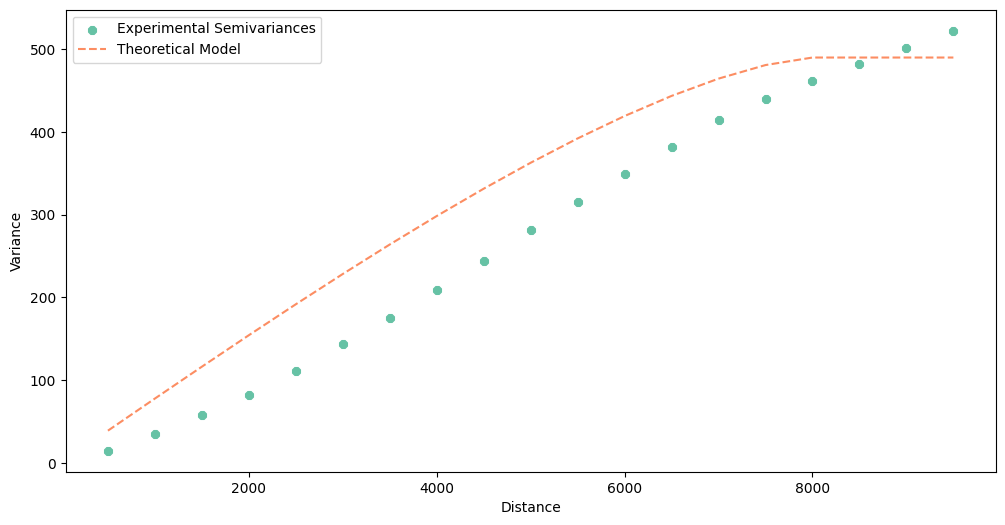

In [58]:
circular_model.plot(experimental=True)

In [59]:
# cubic

cubic_model = build_theoretical_variogram(experimental_variogram=experimental_variogram,
                                          model_name='cubic',
                                          sill=sill,
                                          rang=var_range,
                                          nugget=nugget)

In [60]:
print(cubic_model)

* Selected model: Cubic model
* Nugget: 0
* Sill: 489.8203263077297
* Range: 8000
* Spatial Dependency Strength is Unknown
* Mean Bias: -77.44307814715333
* Mean RMSE: 100.93081804872125
* Error-lag weighting method: None


+--------+--------------------+--------------------+---------------------+
|  lag   |    theoretical     |    experimental    |     bias (y-y')     |
+--------+--------------------+--------------------+---------------------+
| 500.0  | 12.34878902539015  | 14.716058620972868 |  2.3672695955827177 |
| 1000.0 | 45.255288629599086 | 34.85400868491261  | -10.401279944686479 |
| 1500.0 | 92.68405535286398  | 57.712760007769795 | -34.971295345094184 |
| 2000.0 | 148.9805383955685  | 82.49483539006093  |  -66.48570300550756 |
| 2500.0 | 209.04428231682044 | 111.4449493651956  |  -97.59933295162485 |
| 3000.0 | 268.48143737523486 | 143.4007980025356  | -125.08063937269927 |
| 3500.0 | 323.7296800593239  | 175.10704725708965 | -148.62263280223428 |
| 4000.0 | 372.14864635489

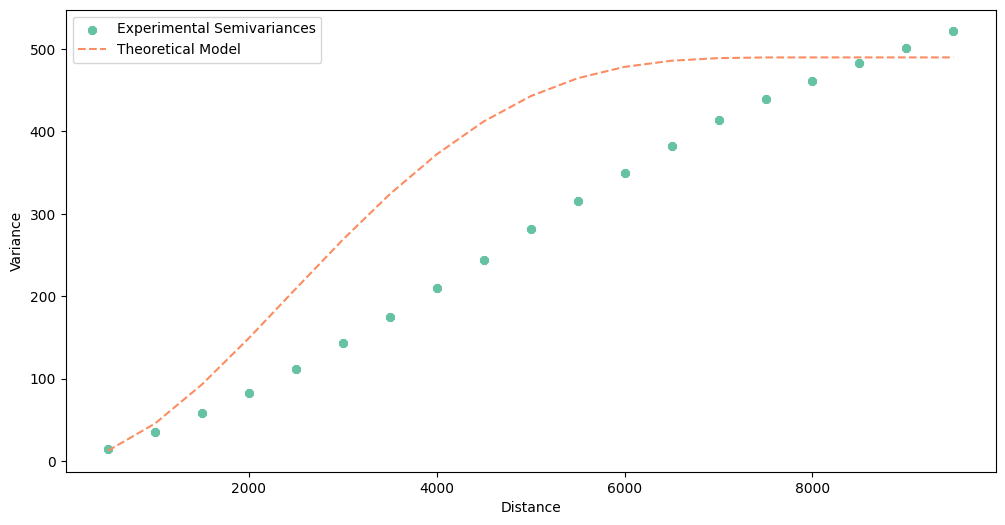

In [61]:
cubic_model.plot()

In [62]:
# Exponential model

exponential_model = build_theoretical_variogram(experimental_variogram=experimental_variogram,
                                                model_name='exponential',
                                                sill=sill,
                                                rang=var_range,
                                                nugget=nugget)
print(exponential_model)

* Selected model: Exponential model
* Nugget: 0
* Sill: 489.8203263077297
* Range: 8000
* Spatial Dependency Strength is Unknown
* Mean Bias: 62.87847144716388
* Mean RMSE: 97.41020702761479
* Error-lag weighting method: None


+--------+--------------------+--------------------+---------------------+
|  lag   |    theoretical     |    experimental    |     bias (y-y')     |
+--------+--------------------+--------------------+---------------------+
| 500.0  | 29.676713342689204 | 14.716058620972868 | -14.960654721716336 |
| 1000.0 | 57.555405518182404 | 34.85400868491261  | -22.701396833269797 |
| 1500.0 | 83.74501312199658  | 57.712760007769795 | -26.032253114226783 |
| 2000.0 | 108.34787261497875 | 82.49483539006093  | -25.853037224917827 |
| 2500.0 | 131.46012020525072 | 111.4449493651956  |  -20.01517084005512 |
| 3000.0 | 153.17206750253146 | 143.4007980025356  |  -9.771269499995867 |
| 3500.0 | 173.56855441271478 | 175.10704725708965 |  1.538492844374872  |
| 4000.0 | 192.7292806

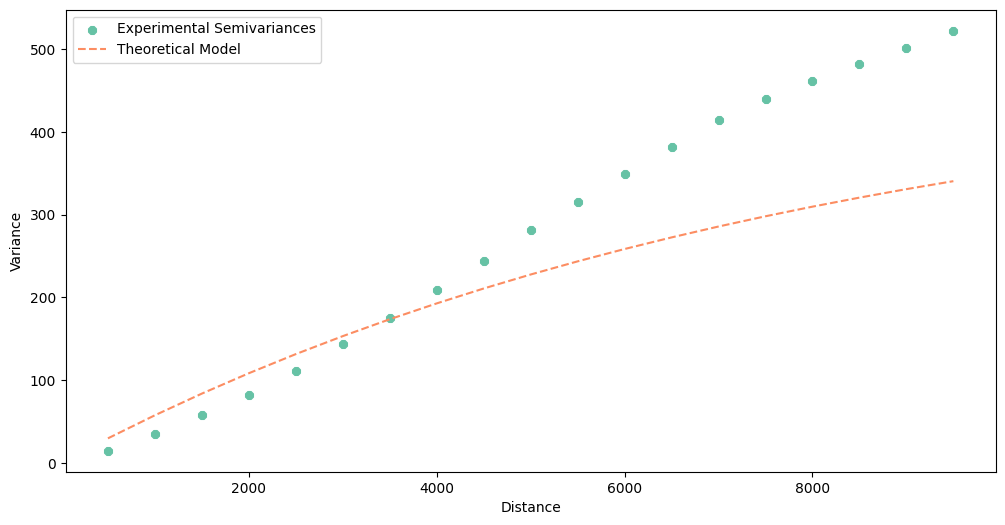

In [63]:
exponential_model.plot()

In [64]:
# Gaussian model

gaussian_model = build_theoretical_variogram(experimental_variogram=experimental_variogram,
                                             model_name='gaussian',
                                             sill=sill,
                                             rang=var_range,
                                             nugget=nugget)
print(gaussian_model)

* Selected model: Gaussian model
* Nugget: 0
* Sill: 489.8203263077297
* Range: 8000
* Spatial Dependency Strength is Unknown
* Mean Bias: 106.76795548020137
* Mean RMSE: 116.3487709038113
* Error-lag weighting method: None


+--------+--------------------+--------------------+--------------------+
|  lag   |    theoretical     |    experimental    |    bias (y-y')     |
+--------+--------------------+--------------------+--------------------+
| 500.0  | 1.9096284783003161 | 14.716058620972868 | 12.806430142672552 |
| 1000.0 | 7.593960284943274  | 34.85400868491261  | 27.26004839996933  |
| 1500.0 | 16.92106251490172  | 57.712760007769795 | 40.791697492868074 |
| 2000.0 | 29.676713342689204 | 82.49483539006093  | 52.81812204737172  |
| 2500.0 | 45.57258050587133  | 111.4449493651956  | 65.87236885932427  |
| 3000.0 | 64.25705194799532  | 143.4007980025356  | 79.14374605454027  |
| 3500.0 | 85.32815073541408  | 175.10704725708965 | 89.77889652167556  |
| 4000.0 | 108.34787261497875 | 20

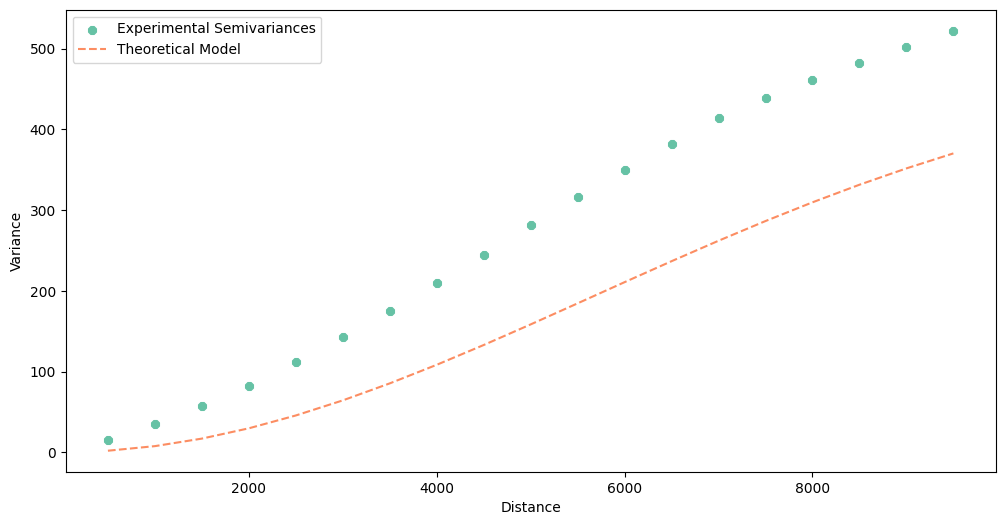

In [65]:
gaussian_model.plot()

In [66]:
# Linear model

linear_model = build_theoretical_variogram(experimental_variogram=experimental_variogram,
                                           model_name='linear',
                                           sill=sill,
                                           rang=var_range,
                                           nugget=nugget)
print(linear_model)

* Selected model: Linear model
* Nugget: 0
* Sill: 489.8203263077297
* Range: 8000
* Spatial Dependency Strength is Unknown
* Mean Bias: -21.58683474038296
* Mean RMSE: 28.218692107535404
* Error-lag weighting method: None


+--------+--------------------+--------------------+---------------------+
|  lag   |    theoretical     |    experimental    |     bias (y-y')     |
+--------+--------------------+--------------------+---------------------+
| 500.0  | 30.613770394233107 | 14.716058620972868 | -15.897711773260239 |
| 1000.0 | 61.227540788466214 | 34.85400868491261  | -26.373532103553607 |
| 1500.0 | 91.84131118269931  | 57.712760007769795 |  -34.12855117492952 |
| 2000.0 | 122.45508157693243 | 82.49483539006093  |  -39.9602461868715  |
| 2500.0 | 153.06885197116554 | 111.4449493651956  | -41.623902605969946 |
| 3000.0 | 183.68262236539863 | 143.4007980025356  | -40.281824362863034 |
| 3500.0 | 214.29639275963174 | 175.10704725708965 | -39.189345502542096 |
| 4000.0 | 244.9101631538

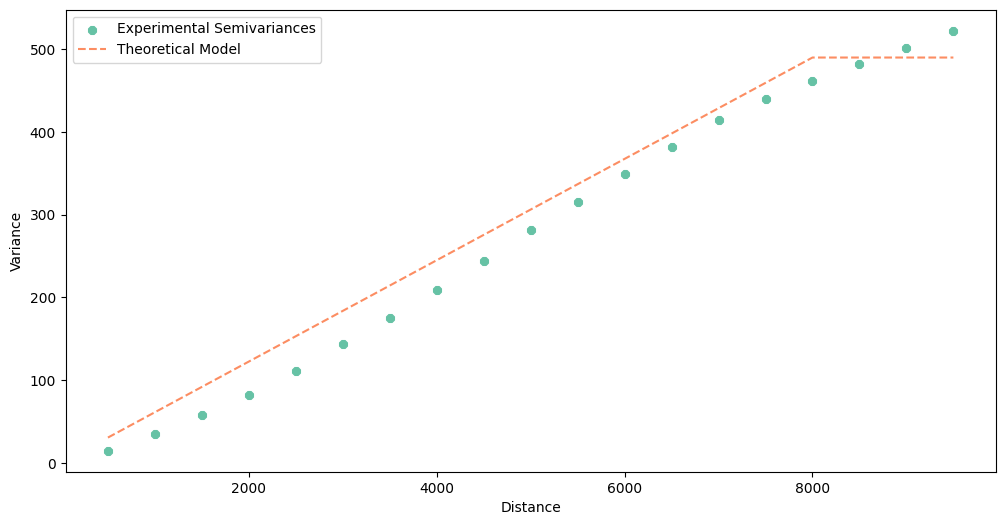

In [67]:
linear_model.plot()

In [68]:
# Power model

power_model = build_theoretical_variogram(experimental_variogram=experimental_variogram,
                                          model_name='power',
                                          sill=sill,
                                          rang=var_range,
                                          nugget=nugget)
print(power_model)

* Selected model: Power model
* Nugget: 0
* Sill: 489.8203263077297
* Range: 8000
* Spatial Dependency Strength is Unknown
* Mean Bias: 46.89133587829636
* Mean RMSE: 58.334699200244835
* Error-lag weighting method: None


+--------+--------------------+--------------------+--------------------+
|  lag   |    theoretical     |    experimental    |    bias (y-y')     |
+--------+--------------------+--------------------+--------------------+
| 500.0  | 1.9133606496395692 | 14.716058620972868 | 12.802697971333298 |
| 1000.0 | 7.653442598558277  | 34.85400868491261  | 27.20056608635433  |
| 1500.0 | 17.22024584675612  | 57.712760007769795 | 40.49251416101367  |
| 2000.0 | 30.613770394233107 | 82.49483539006093  | 51.88106499582782  |
| 2500.0 | 47.83401624098923  | 111.4449493651956  | 63.61093312420637  |
| 3000.0 | 68.88098338702449  | 143.4007980025356  | 74.51981461551111  |
| 3500.0 | 93.75467183233889  | 175.10704725708965 | 81.35237542475076  |
| 4000.0 | 122.45508157693243 | 209.3

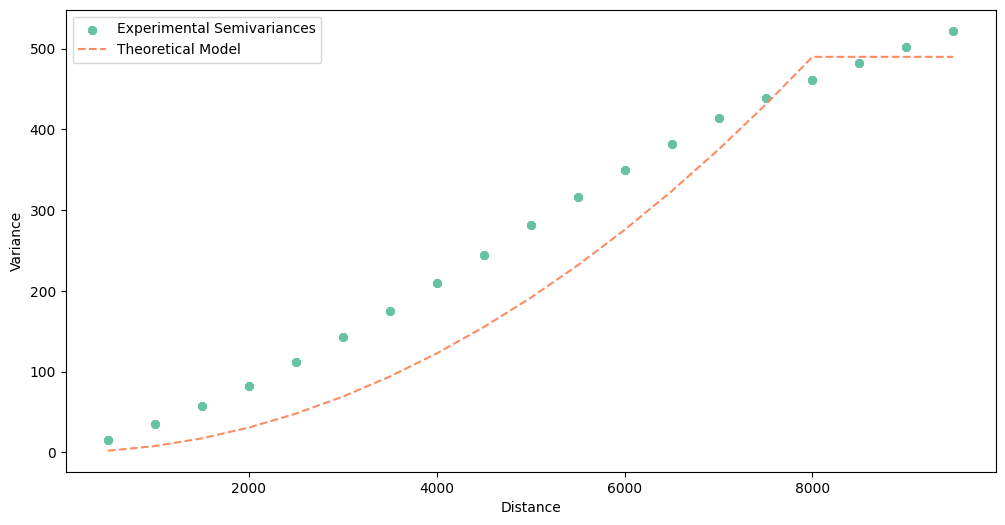

In [69]:
power_model.plot()

In [70]:
# Spherical model

spherical_model = build_theoretical_variogram(experimental_variogram=experimental_variogram,
                                              model_name='spherical',
                                              sill=sill,
                                              rang=var_range,
                                              nugget=nugget)

print(spherical_model)

* Selected model: Spherical model
* Nugget: 0
* Sill: 489.8203263077297
* Range: 8000
* Spatial Dependency Strength is Unknown
* Mean Bias: -72.94546270439245
* Mean RMSE: 87.44243944688779
* Error-lag weighting method: None


+--------+--------------------+--------------------+---------------------+
|  lag   |    theoretical     |    experimental    |     bias (y-y')     |
+--------+--------------------+--------------------+---------------------+
| 500.0  | 45.86086307104843  | 14.716058620972868 |  -31.14480445007556 |
| 1000.0 | 91.36297102028944  | 34.85400868491261  |  -56.50896233537683 |
| 1500.0 | 136.1475687259156  | 57.712760007769795 |  -78.4348087181458  |
| 2000.0 | 179.85590106611951 | 82.49483539006093  |  -97.36106567605859 |
| 2500.0 | 222.12921291909373 | 111.4449493651956  | -110.68426355389813 |
| 3000.0 | 262.6087491630309  | 143.4007980025356  |  -119.2079511604953 |
| 3500.0 | 300.9357546761235  | 175.10704725708965 | -125.82870741903386 |
| 4000.0 | 336.75147433

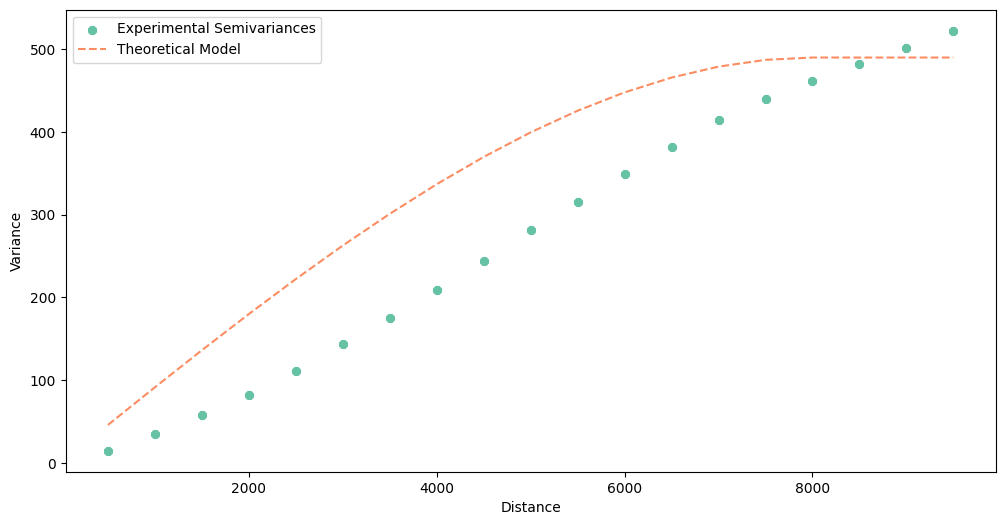

In [71]:
spherical_model.plot()

Rzut oka na wykresy i możemy podjąc decyzję - najlepszy jest model liniowy `linear`. Poleganie na wzrokowym porównaniu może by mylące, dlatego możemy również porównac średni pierwiastek z błędu kwadratowego każdego modelu, pisząc funkcję Pythona, która wybierze model o najniższym błędzie:

In [72]:
models = [
    circular_model, cubic_model, exponential_model, gaussian_model, linear_model, power_model, spherical_model
]

lowest_rmse = np.inf
chosen_model = ''

for _model in models:
    
    # Get attrs
    model_name = _model.name
    model_rmse = _model.rmse
    
    # Check error
    if model_rmse < lowest_rmse:
        lowest_rmse = model_rmse
        chosen_model = model_name
    
    # Print status
    msg = f'Model: {model_name}, średni pierwiastek z błędu kwadratowego: {model_rmse}'
    print(msg)

msg = f'Najlepszy model to model {chosen_model} z błędem RMSE {lowest_rmse}'
print(msg)

Model: circular, średni pierwiastek z błędu kwadratowego: 63.002808575915346
Model: cubic, średni pierwiastek z błędu kwadratowego: 100.93081804872125
Model: exponential, średni pierwiastek z błędu kwadratowego: 97.41020702761479
Model: gaussian, średni pierwiastek z błędu kwadratowego: 116.3487709038113
Model: linear, średni pierwiastek z błędu kwadratowego: 28.218692107535404
Model: power, średni pierwiastek z błędu kwadratowego: 58.334699200244835
Model: spherical, średni pierwiastek z błędu kwadratowego: 87.44243944688779
Najlepszy model to model linear z błędem RMSE 28.218692107535404


## 4) Wyznacz model automatycznie

Automatyczne wyznaczenie modelu ma swoje zalety. Algorytm może przetestować na raz wiele różnych funkcji teoretycznych i zestawów parametrów, minimalizując błąd dopasowania teoretycznego semiwariogramu do eksperymentalnych wartości. Żeby przeprowadzić automatyczne przeszukiwanie musimy zainicjować obiekt typu `TheoreticalVariogram` i wywołać jego metodę `.autofit()`.

Metoda `autofit()` przyjmuje wiele parametrów. Najważniejsze to:

- `experimental_variogram` - obiekt typu `ExperimentalVariogram`,
- `model_name` albo `model_types` - pierwszy argument to po prostu nazwa funkcji teoretycznej. Drugi argument to lista różnych modeli do przetestowania, jeśli go podasz, wtedy algorytm sprawdzi każdą funkcję teoretyczną z listy. Podstawowe modele dla parametru `model_name` to:
  - `circular`
  - `cubic`
  - `exponential`
  - `gaussian`
  - `linear`
  - `power`
  - `spherical`
  - (*) `all`: sprawdź każdy dostępny model
  - (*) `safe`: sprawdź modele: `linear`, `spherical`, `power`

Jeśli pojedynczy model albo grupy modeli dla parametrów `all` i `safe` nie są dla nas zadowalające, możemy podać funkcji listę z innymi modelami w parametrze `model_types`, przykładowo `model_types=['circular', 'power']`.

Pozostałe parametry metody `autofit()`:

- `nugget` - nugget (niepewność obserwacji), jeśli jest podana, wtedy traktowana jest jako stała.
- `min_nugget` - minimalna wartość nugget do sprawdzenia, jest definiowana jako `min_nugget * wariancja`, domyślnie równa się `0.0`.
- `max_nugget` - maksymalna wartość nugget do sprawdzenia, jest definiowana jako `max_nugget * wariancja`, domyślnie równa się `0.5`, czyli może być równa połowie wariancji.
- `number_of_nuggets` - jak wiele równoodległych przedziałów między `min_nugget` a `max_nugget` powinno być sprawdzone, domyślnie `16`.
- `rang` - zasięg analizy, jeśli jest podany, wtedy traktowany jako stała.
- `min_range` - minimalny zasięg do sprawdzenia, definiowany jako `min_range * D`, gdzie `D` to największa odległość między bokami prostokąta opisującymi obszar analizy, domyślnie równe `0.1`.
- `max_range` - maksymalny zasięg do sprawdzenia, definiowany jako `max_range * D`, gdzie `D` to największa odległość między bokami prostokąta opisującymi obszar analizy, domyślnie równe `0.5`.
- `number_of_ranges` - jak wiele równoodległych przedziałów między `min_range` a `max_range` powinno być sprawdzone, domyślnie `16`.
- `sill` - wysycenie (maksymalna miara niepodobieństwa), jeśli jest podana, wtedy traktowana jako stała.
- `min_sill` - minimalna część wariancji `W` w danych, liczona jako `min_sill * W`. Domyślnie `min_sill` jest równe `0`.
- `max_sill` - maksymalna część wariancji `W` w danych, liczona jako `max_sill * W`. Domyślnie `max_sill` jest równe `1`. Może być większe niż 1, choć program traktuje to jako błąd i wyświetla **Warning** - ostrzeżenie (które nie przerywa procesu).
- `number_of_sills` - jak wiele równoodległych przedziałów między `min_sill` a `max_sill` jest sprawdzone, domyślnie `16`.
- `error_estimator` - metoda pomiaru błędu między eksperymentalnym a teoretycznym wariogramem, domyślnie `rmse` spośród:
  - **rmse**: Root Mean Squared Error,
  - **mae**: Mean Absolute Error,
  - **bias**: Forecast Bias,
  - **smape**: Symmetric Mean Absolute Percentage Error.

W pierwszym przebiegu ustawimy *sill*, *rang* i *nugget* na stałe wartości i zobaczymy który model teoretyczny zostanie wybrany przez algorytm:

In [73]:
semivariogram_model = TheoreticalVariogram()

In [74]:
fitted = semivariogram_model.autofit(
    experimental_variogram=experimental_variogram,
    model_name='all',
    nugget=0,
    rang=var_range,
    sill=sill)

In [75]:
fitted

{'model_name': 'linear',
 'nugget': 0,
 'sill': 489.8203263077297,
 'range': 8000,
 'fitted_model': array([[ 500.        ,   30.61377039],
        [1000.        ,   61.22754079],
        [1500.        ,   91.84131118],
        [2000.        ,  122.45508158],
        [2500.        ,  153.06885197],
        [3000.        ,  183.68262237],
        [3500.        ,  214.29639276],
        [4000.        ,  244.91016315],
        [4500.        ,  275.52393355],
        [5000.        ,  306.13770394],
        [5500.        ,  336.75147434],
        [6000.        ,  367.36524473],
        [6500.        ,  397.97901513],
        [7000.        ,  428.59278552],
        [7500.        ,  459.20655591],
        [8000.        ,  489.82032631],
        [8500.        ,  489.82032631],
        [9000.        ,  489.82032631],
        [9500.        ,  489.82032631]]),
 'rmse': 28.218692107535404,
 'bias': nan,
 'mae': nan,
 'smape': nan}

Automatyczne przeszukanie wybrało model liniowy. Teraz zwiększymy zakres przeszukań o optymalne *sill* i *rang*, zobaczymy, który model okaże się najlepszy w tym scenariuszu:

In [76]:
fitted = semivariogram_model.autofit(experimental_variogram=experimental_variogram, nugget=0, model_name='all')

In [81]:
fitted

{'model_name': 'cubic',
 'nugget': 0,
 'sill': 489.8203263077297,
 'range': 12335.489979757927,
 'fitted_model': array([[5.00000000e+02, 5.34805582e+00],
        [1.00000000e+03, 2.02557839e+01],
        [1.50000000e+03, 4.30386760e+01],
        [2.00000000e+03, 7.20566873e+01],
        [2.50000000e+03, 1.05735635e+02],
        [3.00000000e+03, 1.42587601e+02],
        [3.50000000e+03, 1.81229998e+02],
        [4.00000000e+03, 2.20402979e+02],
        [4.50000000e+03, 2.58984845e+02],
        [5.00000000e+03, 2.96005120e+02],
        [5.50000000e+03, 3.30654972e+02],
        [6.00000000e+03, 3.62294630e+02],
        [6.50000000e+03, 3.90457480e+02],
        [7.00000000e+03, 4.14850490e+02],
        [7.50000000e+03, 4.35350655e+02],
        [8.00000000e+03, 4.51997098e+02],
        [8.50000000e+03, 4.64978532e+02],
        [9.00000000e+03, 4.74615706e+02],
        [9.50000000e+03, 4.81338548e+02]]),
 'rmse': 15.444756774880005,
 'bias': nan,
 'mae': nan,
 'smape': nan}

Metoda `.autofit()` wybrała inne parametry niż te, które ustawiliśmy na początku. Dzięki temu wskaźnik pierwiastka ze średniego błędu kwadratowego uległ poprawie o ponad 45%!

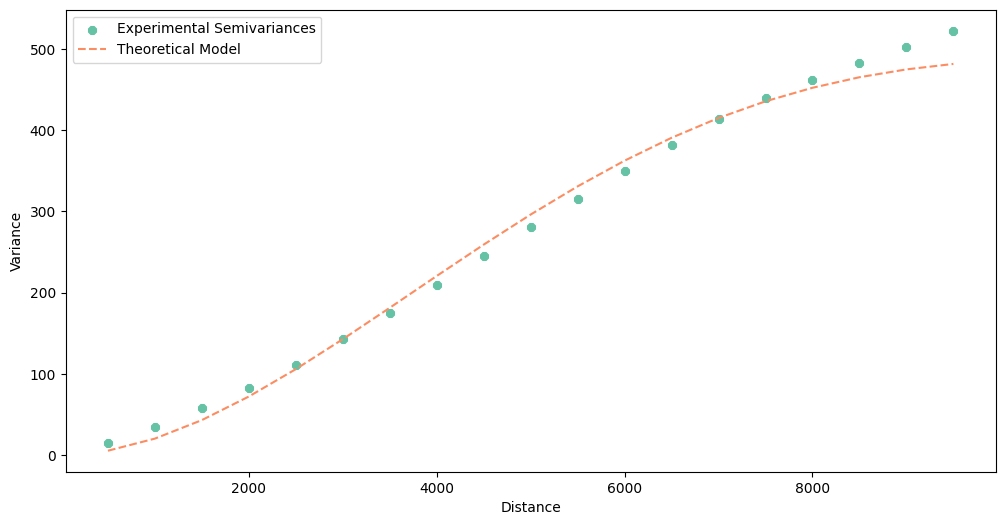

In [78]:
semivariogram_model.plot()

Porównajmy oba modele - wyliczony automatycznie i ręcznie:

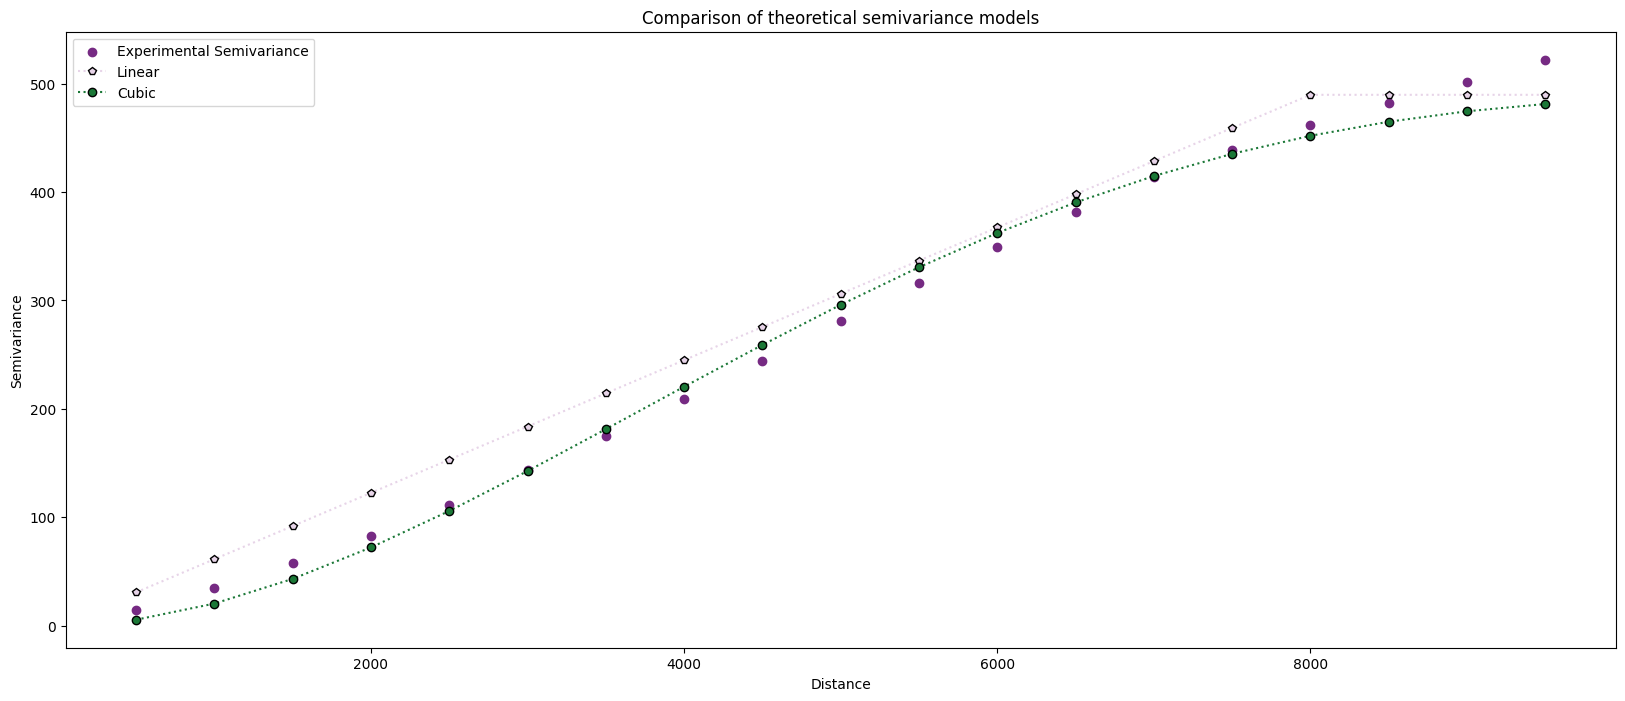

In [79]:
_lags = semivariogram_model.lags

plt.figure(figsize=(20, 8))
plt.scatter(_lags, experimental_variogram.experimental_semivariances, color='#762a83')  # Experimental
plt.plot(_lags, linear_model.fitted_model[:, 1], ':p', color='#e7d4e8', mec='black')
plt.plot(_lags, semivariogram_model.fitted_model[:, 1], ':o', color='#1b7837', mec='black')
plt.title('Comparison of theoretical semivariance models')
plt.legend(['Experimental Semivariance',
            'Linear',
            'Cubic'])
plt.xlabel('Distance')
plt.ylabel('Semivariance')
plt.show()

## 5) Eksport modelu

Parametry teoretycznego semiwariogramu mogą zostać wyeksportowane, co pozwala na ich późniejsze wykorzystanie, na przykład w procesie **regularyzacji semiwariogramu**. Znajdowanie najlepszego modelu jest kosztowne obliczeniowo, dlatego możliwość przechowania wyników skraca wiele procesów.

Model może być eksportowany do słownika `dict` za pomocą metody `.to_dict()`, albo do struktury `json` uruchamiając metodę `.to_json()`:

In [82]:
# Model do słownika

dict_model = semivariogram_model.to_dict()

# Model do pliku
semivariogram_model.to_json('../../tutorials-output/semivariogram_calculation_model.json')

## 6) Import modelu

Importujemy model do instancji klasy **TheoreticalSemivariogram**.

Służą temu dwie metody: `.from_dict()` wczytująca parametry ze słownika oraz `.from_json()` ładująca parametry modelu z pliku.

In [83]:
other_model_from_dict = TheoreticalVariogram()

print(other_model_from_dict)

Theoretical model is not calculated yet. Use fit() or autofit() methods to build or find a model or import model with from_dict() or from_json() methods.


In [84]:
other_model_from_dict.from_dict(dict_model)
print(other_model_from_dict)

* Selected model: Cubic model
* Nugget: 0.0
* Sill: 489.8203263077297
* Range: 12335.489979757927
* Spatial Dependency Strength is Unknown
* Mean Bias: 0.0
* Mean RMSE: 0.0
* Error-lag weighting method: None


In [85]:
other_model_from_json = TheoreticalVariogram()
print(other_model_from_json)

Theoretical model is not calculated yet. Use fit() or autofit() methods to build or find a model or import model with from_dict() or from_json() methods.


In [87]:
other_model_from_json.from_json('../../tutorials-output/semivariogram_calculation_model.json')

In [88]:
print(other_model_from_json)

* Selected model: Cubic model
* Nugget: 0.0
* Sill: 489.8203263077297
* Range: 12335.489979757927
* Spatial Dependency Strength is Unknown
* Mean Bias: 0.0
* Mean RMSE: 0.0
* Error-lag weighting method: None


---

Który samouczek na teraz?

* A.1.2 Funkcje opisujące semiwariogram
* A.1.3 Spatial Dependence Index - indeks zależności przestrzennych
* A.2.1 Kierunkowy Semiwariogram
* A.2.2 Chmura punktów
* A.2.3 Klasy eksperymentalnego wariogramu
* B.1.1 Techniki Ordinary Kriging i Simple Kriging

## Dziennik zmian

| Data       | Opis zmiany                                                                                                               | Autor |
|------------|---------------------------------------------------------------------------------------------------------------------------|-------|
| 2024-03-23 | Pierwsza wersja samouczka po polsku                                                                                       | @SimonMolinsky |
